In [1]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
import snapatac2 as snap
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Spatial Coord

In [5]:
file_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/artifacts/stereo_seq_spinal_cord_gwall/results/single_sample/27052025_044245/stereo_seq_spinal_cord_gwall_analysis.h5ad"
adata = sc.read_h5ad(file_path)
adata

AnnData object with n_obs × n_vars = 82934 × 8000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'batch', 'latent_leiden_0.3', 'Add-on_31_GP', 'Add-on_72_GP', 'PTPN11_ligand_receptor_GP', 'SERPING1_ligand_receptor_target_gene_GP', 'INHBA_combined_GP', 'FGF18_combined_GP', 'ST6GAL1_ligand_receptor_target_gene_GP', 'BST2_combined_GP', 'VSIG10_ligand_receptor_target_gene_GP', 'Heme_metabolite_enzyme_sensor_GP', 'CCL2_combined_GP', 'TGFB2_combined_GP', 'LMAN1_ligand_receptor_GP', 'LEPR_ligand_receptor_GP', 'ITIH2_ligand_receptor_target_gene_GP', 'ANGPTL1_combined_GP', 'IL19_combined_GP', 'IFITM1_ligand_receptor_target_gene_GP', 'COL15A1_combined_GP', 'SDC4_ligand_receptor_target_gene_GP', 'PGF_combined_GP', 'LAMC3_ligand_receptor_target_gene_GP', 'ILDR2_ligand_receptor_target_gene_GP', 'COL1A2_ligand_receptor_target_gene_GP', 'COL3A1_ligand_receptor_target_gene_GP', 'SPON2_combined_GP', 'L-Tyrosine_metabolite_enzyme_sensor_GP', 'IGSF11_ligand

In [6]:
cod = adata.obs[['x', 'y']]
cod.to_csv('spatial_coord.csv', index=True)

# Spatial Accessibility reconstructed

In [5]:
data = snap.read_dataset("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads")
adata = data.to_adata()
data.close()

AnnDataSet object with n_obs x n_vars = 109782 x 606219 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'reference_sequences', 'AnnDataSet'
    obsm: 'fragment_paired'

In [8]:
adata

AnnData object with n_obs × n_vars = 109782 × 606219
    obs: 'sample'
    uns: 'reference_sequences', 'AnnDataSet'
    obsm: 'fragment_paired'

In [4]:
import os
# Base directory containing per-sample CSV files
base_path = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping'

# Sample order
samples = ["GW6", "GW12", "GW7", "GW9", "GW10", "GW16", "GW17", "GW20"] # This order differs from older analyses because the multi-mapping step already corrected indices; the tail index for GW6 and GW7 needs to be reversed accordingly.

# Collect all dataframes
df_list = []

for idx, sample in enumerate(samples):
    file_path = os.path.join(base_path, sample, 'link_st_matrix.csv')
    
    if os.path.exists(file_path):
        # Read CSV
        df = pd.read_csv(file_path)
        
        # Ensure id_rna is a string
        df['id_rna'] = df['id_rna'].astype(str)
        
        # Append a batch suffix: original barcode + '-' + batch index
        df['id_rna_merge'] = df['id_rna'] + '-' + str(idx)
        
        # Add sample label for downstream sanity checks (optional)
        df['sample_batch'] = sample
        
        df_list.append(df)
    else:
        print(f"Warning: File not found for {sample} at {file_path}")

merged_df = pd.concat(df_list, ignore_index=True)

# Valid barcodes to keep
valid_barcodes = set(merged_df['id_rna_merge'].values)

# Keep cells present in the mapping table
mask = adata.obs_names.isin(valid_barcodes)

# Subset AnnData
adata_spatial = adata[mask].copy()

# Map additional columns back to AnnData (e.g., id_st, cluster_rna)
info_mapper = merged_df.set_index('id_rna_merge')

# Annotate id_st and cluster_rna in adata.obs
adata_spatial.obs['id_st'] = adata_spatial.obs_names.map(info_mapper['id_st'])
adata_spatial.obs['cluster_rna'] = adata_spatial.obs_names.map(info_mapper['cluster_rna'])

In [5]:
adata_spatial.obs

,sample,id_st,cluster_rna
AAACAGCCAGCAAGAT-1-0,GW7,GW7:5640_6180,ventral_glia
AAACAGCCATAAAGCA-1-0,GW7,GW7:5130_6390,v0/1
AAACCAACAACTAGAA-1-0,GW7,GW7:5370_5790,ExN_immature-2
AAACCAACACCTATAG-1-0,GW7,GW7:5490_5880,v0/1
AAACCGAAGGTCCACA-1-0,GW7,GW7:4770_6120,NPC
...,...,...,...
TTTGTGGCAGTAGGTG-1-6,GW17,GW17:11880_19080,di4/6-1
TTTGTGTTCAAACACC-1-6,GW17,GW17:13500_21690,di3/5-3
TTTGTGTTCATCACTT-1-6,GW17,GW17:13650_21660,di3/5-2
TTTGTTGGTCCCGGAA-1-6,GW17,GW17:11970_18090,di3/5-1


In [6]:
%%time
snap.tl.macs3(adata_spatial, groupby='cluster_rna', qvalue=0.01, blacklist='/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hg38-blacklist.v2.bed')

2026-01-14 17:05:26 - INFO - Exporting fragments...
2026-01-14 17:06:13 - INFO - Calling peaks...
100%|██████████| 86/86 [06:54<00:00,  4.82s/it]


CPU times: user 6min 14s, sys: 23.9 s, total: 6min 38s
Wall time: 7min 43s


In [7]:
%%time
peaks = snap.tl.merge_peaks(adata_spatial.uns['macs3'], snap.genome.hg38)
peaks.shape

CPU times: user 6.12 s, sys: 715 ms, total: 6.84 s
Wall time: 4.93 s


(337799, 87)

In [8]:
chrom = peaks['Peaks']
chrom.to_pandas().to_csv('cCREs.csv', index=False)

In [9]:
%%time
peak_mat = snap.pp.make_peak_matrix(adata_spatial, use_rep=peaks['Peaks'])
peak_mat

CPU times: user 8min 24s, sys: 10.1 s, total: 8min 34s
Wall time: 20.6 s


AnnData object with n_obs × n_vars = 30470 × 337799
    obs: 'sample', 'id_st', 'cluster_rna'

In [10]:
peak_mat.uns['reference_sequences'] = adata_spatial.uns['reference_sequences']
peak_mat.obsm['fragment_paired'] = adata_spatial.obsm['fragment_paired']

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse
import scanpy.external as sce
import os

# Target sample list
target_samples = ["GW6", "GW7", "GW9", "GW10", "GW12", "GW16", "GW17"]


# Spatial coordinates path
spatial_path = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/spatial_coord.csv'
spatial_df = pd.read_csv(spatial_path, index_col=0)
if 'x' not in spatial_df.columns:
    spatial_df.columns = ['x', 'y']

# Output folder
output_folder = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/reconstructed_SpATAC'
os.makedirs(output_folder, exist_ok=True)

for batch in target_samples:
    print(f"\n>>> Processing Sample: {batch}")
    
    # --- Load full spatial coordinates for the current batch (reference) ---
    batch_spatial_df = spatial_df[spatial_df.index.str.startswith(batch + ":")]
    
    if len(batch_spatial_df) == 0:
        print(f"  [Warn] No spatial coordinates found starting with '{batch}:'. Skipping.")
        continue
    
    print(f"  - Spatial spots (Background + Signal): {len(batch_spatial_df)}")

    # --- Load ATAC data for the current batch (source) ---
    batch_atac = peak_mat[peak_mat.obs['sample'] == batch].copy()
    
    if batch_atac.n_obs == 0:
        print(f"  [Warn] No ATAC cells found for sample '{batch}'. Skipping.")
        continue

    # Temporarily set ATAC index to id_st to align with spatial_df
    batch_atac.obs.index = batch_atac.obs['id_st'].values
    batch_atac.obs_names_make_unique()
    
    # --- Compute intersection and complement ---
    # Intersection: spots that have both spatial coordinates and ATAC signal
    common_ids = list(set(batch_atac.obs_names) & set(batch_spatial_df.index))
    # Complement: spots with spatial coordinates but no ATAC signal (will be zero-filled)
    missing_ids = list(set(batch_spatial_df.index) - set(batch_atac.obs_names))
    
    print(f"  - Matched cells: {len(common_ids)}")
    print(f"  - Missing cells (to be zero-filled): {len(missing_ids)}")
    
    if len(common_ids) == 0:
        print(f"  [Error] No overlap between ATAC id_st and Spatial index. Check prefixes!")
        continue

    # --- Build merged matrix ---
    # Keep the observed part
    obj_filtered = batch_atac[common_ids].copy()
    
    # Build the zero-filled part
    if len(missing_ids) > 0:
        num_genes = batch_atac.shape[1]
        # Create a sparse zero matrix
        zeros_matrix = scipy.sparse.csr_matrix((len(missing_ids), num_genes), dtype=np.float32)
        
        # Build matching obs
        new_obs = pd.DataFrame(index=missing_ids)
        new_obs['sample'] = batch
        new_obs['id_st'] = missing_ids
        new_obs['cluster_rna'] = 'Background' # Mark as background
        
        new_adata = ad.AnnData(
            X=zeros_matrix,
            obs=new_obs,
            var=batch_atac.var.copy()
        )
        combined_adata = ad.concat([obj_filtered, new_adata], axis=0)
    else:
        combined_adata = obj_filtered.copy()
    
    # --- Spatial alignment ---
    # Reorder by spatial_df and assign coordinates
    combined_adata = combined_adata[batch_spatial_df.index].copy()
    combined_adata.obsm['spatial'] = batch_spatial_df[['x', 'y']].values
    
    print(f"  - AnnData constructed: {combined_adata.shape}")

    # --- Preprocessing (MAGIC) ---
    print("  - Preprocessing...")
    
    # Filter out all-zero peaks
    # Note: min_cells=1 may result in slightly different peak sets across samples
    sc.pp.filter_genes(combined_adata, min_cells=1)
    
    if combined_adata.n_vars == 0:
        print("  [Error] All peaks filtered out (likely no signal). Skipping.")
        continue
    
    # MAGIC imputation
    # solver='approximate' is important for large peak matrices
    sce.pp.magic(combined_adata, name_list='all_genes', solver="approximate")
    
    # --- Save ---
    save_filename = f"Spatial_ATAC_{batch}.h5ad"
    save_full_path = os.path.join(output_folder, save_filename)
    
    combined_adata.write(save_full_path)
    print(f"  - Saved to: {save_full_path}")


>>> Processing Sample: GW6
  - Spatial spots (Background + Signal): 3301
  - Matched cells: 3053
  - Missing cells (to be zero-filled): 248
  - AnnData constructed: (3301, 337799)
  - Preprocessing...


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 1860 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)
... storing 'sample' as categorical
... storing 'cluster_rna' as categorical


  - Saved to: /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/reconstructed_SpATAC/Spatial_ATAC_GW6.h5ad

>>> Processing Sample: GW7
  - Spatial spots (Background + Signal): 1926
  - Matched cells: 1638
  - Missing cells (to be zero-filled): 288
  - AnnData constructed: (1926, 337799)
  - Preprocessing...


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 2160 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)
... storing 'sample' as categorical
... storing 'cluster_rna' as categorical


  - Saved to: /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/reconstructed_SpATAC/Spatial_ATAC_GW7.h5ad

>>> Processing Sample: GW9
  - Spatial spots (Background + Signal): 4324
  - Matched cells: 3629
  - Missing cells (to be zero-filled): 695
  - AnnData constructed: (4324, 337799)
  - Preprocessing...


...

/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 107662 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)
... storing 'sample' as categorical
... storing 'cluster_rna' as categorical


  - Saved to: /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/reconstructed_SpATAC/Spatial_ATAC_GW16.h5ad

>>> Processing Sample: GW17
  - Spatial spots (Background + Signal): 30747
  - Matched cells: 5239
  - Missing cells (to be zero-filled): 25508
  - AnnData constructed: (30747, 337799)
  - Preprocessing...


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 191310 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)
... storing 'sample' as categorical
... storing 'cluster_rna' as categorical


  - Saved to: /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/reconstructed_SpATAC/Spatial_ATAC_GW17.h5ad


: 

In [27]:
import scanpy as sc
import anndata as ad
import os
import pandas as pd
import numpy as np

# Paths and sample list
input_folder = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/reconstructed_SpATAC'
target_samples = ["GW6", "GW7", "GW9", "GW10", "GW12", "GW16", "GW17"]

adatas_dict = {}
for batch in target_samples:
    # Build filename
    file_name = f"Spatial_ATAC_{batch}.h5ad"
    file_path = os.path.join(input_folder, file_name)
    
    if os.path.exists(file_path):
        print(f"Loading {batch} ...")
        temp_adata = sc.read_h5ad(file_path)
        
        # Ensure the sample label exists and is correct
        temp_adata.obs['batch'] = batch 
        
        # To avoid metadata conflicts during merging, keep only core obs (optional)
        # temp_adata.obs = temp_adata.obs[['batch', 'id_st', 'cluster_rna']]
        
        adatas_dict[batch] = temp_adata
    else:
        print(f"Warning: File not found for {batch}: {file_path}")

Loading GW6 ...
Loading GW7 ...
Loading GW9 ...
Loading GW10 ...
Loading GW12 ...
Loading GW16 ...
Loading GW17 ...


In [28]:
adatas_dict

{'GW6': AnnData object with n_obs × n_vars = 3301 × 329482
     obs: 'sample', 'id_st', 'cluster_rna', 'batch'
     var: 'n_cells'
     obsm: 'spatial',
 'GW7': AnnData object with n_obs × n_vars = 1926 × 304912
     obs: 'sample', 'id_st', 'cluster_rna', 'batch'
     var: 'n_cells'
     obsm: 'spatial',
 'GW9': AnnData object with n_obs × n_vars = 4324 × 332761
     obs: 'sample', 'id_st', 'cluster_rna', 'batch'
     var: 'n_cells'
     obsm: 'spatial',
 'GW10': AnnData object with n_obs × n_vars = 8551 × 334078
     obs: 'sample', 'id_st', 'cluster_rna', 'batch'
     var: 'n_cells'
     obsm: 'spatial',
 'GW12': AnnData object with n_obs × n_vars = 13046 × 334010
     obs: 'sample', 'id_st', 'cluster_rna', 'batch'
     var: 'n_cells'
     obsm: 'spatial',
 'GW16': AnnData object with n_obs × n_vars = 21039 × 333317
     obs: 'sample', 'id_st', 'cluster_rna', 'batch'
     var: 'n_cells'
     obsm: 'spatial',
 'GW17': AnnData object with n_obs × n_vars = 30747 × 334388
     obs: 'sampl

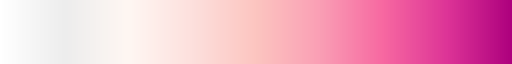

In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Create a gradient colormap
access_colors = ["white", "#EDEDED", "#FFF7F3", "#FDE0DD", "#FCC5C0", "#FA9FB5", 
                 "#F768A1", "#DD3497", "#AE017E"]
access_cmap = LinearSegmentedColormap.from_list("my_cmap", access_colors, N=256)
access_cmap

In [31]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import scanpy as sc

# Inspect peaks in a given sample, e.g. print(adatas_dict['GW6'].var_names[:5])
peak_list = [
    'chr12:102957362-102957863',  # ASCL1 promoter
    'chr12:102950253-102950754',  # ASCL1 enhancer
    'chr3:142149319-142149820',  #  TFDP2 promoter
    'chr3:142027648-142028149',  #  TFDP2 enhancer
    'chr7:55018712-55019213',  # EGFR promoter
    'chr7:54888366-54888867',  # EGFR enhancer
]

# Ensure sample order
target_samples = ["GW7", "GW6", "GW9", "GW10", "GW12", "GW16", "GW17"]

sc.settings.set_figure_params(dpi=300, facecolor='white')
spot_size = 30 

n_peaks = len(peak_list)
n_samples = len(target_samples)

# Compute figure size
fig_width = 4 * n_samples 
fig_height = 4 * n_peaks
fig, axes = plt.subplots(n_peaks, n_samples, figsize=(fig_width, fig_height))

# Start plotting
with PdfPages('./plots/Neuron_access_along_trajectory_spatial.pdf') as pdf:
    # Outer loop: samples (columns)
    for col_idx, batch in enumerate(target_samples):
        
        # Get the current sample AnnData from the dict
        current_adata = adatas_dict.get(batch)
        
        # Inner loop: peaks (rows)
        for row_idx, peak in enumerate(peak_list):
            
            # --- Get the current subplot axis ---
            if n_peaks > 1 and n_samples > 1:
                ax = axes[row_idx, col_idx]
            elif n_peaks > 1:
                ax = axes[row_idx]
            elif n_samples > 1:
                ax = axes[col_idx]
            else:
                ax = axes
            
            # --- Decide whether to plot ---
            should_plot = False
            if current_adata is not None:
                # Check whether this peak exists in current_adata.var_names
                # Note: peak sets may differ slightly across samples (no outer join performed)
                if peak in current_adata.var_names:
                    should_plot = True
            
            # --- Plot ---
            if should_plot:
                try:
                    sc.pl.spatial(
                        adata=current_adata,
                        color=peak,
                        cmap=access_cmap,
                        spot_size=spot_size,
                        title='', 
                        legend_loc=None,
                        vmax=2,
                        frameon=False,  # Remove border
                        ax=ax,
                        show=False
                    )
                except Exception as e:
                    print(f"  Error plotting {peak} in {batch}: {e}")
                    should_plot = False # On error, leave it blank
            
            # --- Blank panel handling (if nothing to plot) ---
            if not should_plot:
                ax.set_xticks([])
                ax.set_yticks([])
                # Hide spines to keep a clean white background
                for spine in ax.spines.values():
                    spine.set_visible(False)
            
            # --- Labels & styling ---
            
            # Row label: peak name (only show on the first column)
            if col_idx == 0:
                ax.text(-0.1, 0.5, peak, 
                        transform=ax.transAxes, 
                        fontsize=10, fontweight='bold', 
                        va='center', ha='right', rotation='vertical')
            else:
                ax.set_ylabel('')

            # Column label: sample name (only show on the first row)
            if row_idx == 0:
                ax.text(0.5, 1.1, batch, 
                        transform=ax.transAxes, 
                        fontsize=14, fontweight='bold', 
                        va='bottom', ha='center')
            else:
                ax.set_title('')
                
            # Extra safeguard: remove ticks
            ax.set_xticks([])
            ax.set_yticks([])

    # Save and close
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()